In [4]:
import sys
print(sys.executable)

c:\Users\Kevin\miniforge3\envs\aikb\python.exe


In [5]:
%pip install sentence-transformers pandas scikit-learn matplotlib plotly jieba

  Using cached sentence_transformers-5.6.0-py3-none-any.whl.metadata (18 kB)
  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
     ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
     ----------------------- --------------- 11.5/19.2 MB 60.0 MB/s eta 0:00:01
     ---------------------------------------- 19.2/19.2 MB 55.1 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.21.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.26.8-py3-none-any.whl.metadata (15 kB)
  Using cached safeten

In [ ]:
import sentence_transformers, pandas, sklearn
print("environment ready")

c:\Users\Kevin\miniforge3\envs\aikb\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


环境就绪


# 阶段 1：AI 使用画像（时间序列 EDA）

先用合成数据练手，等真实导出准备好了随时可以换成 `src/parsing/chatgpt_parser.py` 的输出。

目标表结构和解析器产出的一致：`conversation_id, turn, role, timestamp, text`。

第一步：造一份"看起来像真实使用习惯"的假数据——故意加入夜间高峰、全年增长趋势这些模式，这样后面统计出来的图才有东西可看，不是纯噪声。

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N_CONVERSATIONS = 150
DATE_RANGE = pd.date_range("2025-01-01", "2025-12-31", freq="D")

# 模拟"夜猫子型"用户：晚上9点到凌晨1点是高峰，白天工作时段较低
HOUR_WEIGHTS = np.array([
    0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.2, 0.3,
    0.8, 1.0, 1.0, 0.9, 0.8, 0.9, 1.0, 1.0,
    1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 2.5, 1.5,
])
HOUR_WEIGHTS = HOUR_WEIGHTS / HOUR_WEIGHTS.sum()

# 全年使用量缓慢增长的趋势
DAY_WEIGHTS = np.linspace(0.5, 1.5, len(DATE_RANGE))
DAY_WEIGHTS = DAY_WEIGHTS / DAY_WEIGHTS.sum()

TOPIC_PHRASES = {
    "代码调试": ["这段代码报错了", "为什么会抛异常", "帮我看看这个bug", "怎么优化这个函数"],
    "写作润色": ["帮我润色这段话", "这句话怎么表达更自然", "帮我写一段开头"],
    "求职规划": ["这份简历怎么改", "面试官可能会问什么", "要不要跳槽"],
    "概念学习": ["能不能讲讲这个原理", "这个公式怎么推导", "这两个概念有什么区别"],
}
topics = list(TOPIC_PHRASES.keys())

rows = []
for conv_id in range(1, N_CONVERSATIONS + 1):
    day = rng.choice(DATE_RANGE, p=DAY_WEIGHTS)
    hour = rng.choice(24, p=HOUR_WEIGHTS)
    minute = rng.integers(0, 60)
    t = pd.Timestamp(day) + pd.Timedelta(hours=int(hour), minutes=int(minute))

    topic = rng.choice(topics)
    n_turns = rng.integers(2, 13)  # 2~12条消息，user/assistant交替

    for turn in range(n_turns):
        role = "user" if turn % 2 == 0 else "assistant"
        phrase = rng.choice(TOPIC_PHRASES[topic])
        rows.append({
            "conversation_id": f"conv_{conv_id:04d}",
            "turn": turn,
            "role": role,
            "timestamp": t,
            "text": f"{phrase}（{topic}，第{turn + 1}轮）",
        })
        t += pd.Timedelta(seconds=int(rng.integers(10, 300)))

df = pd.DataFrame(rows)
df.shape

(1050, 5)

## 时间特征工程

用 `.dt` 访问器从 `timestamp` 拆出 `hour`、`weekday`、`month` 三个字段。

注意 `weekday` 用 `.dt.day_name()` 拿到的是字符串（"Monday"...），后面画图时要按周一到周日的顺序排，不能直接按字母排序。

In [6]:
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

df[["timestamp", "hour", "weekday", "month"]].head()

,timestamp,hour,weekday,month
0,2025-11-03 17:25:00,17,Monday,2025-11
1,2025-11-03 17:26:08,17,Monday,2025-11
2,2025-10-31 21:58:00,21,Friday,2025-10
3,2025-10-31 22:00:20,22,Friday,2025-10
4,2025-10-31 22:02:17,22,Friday,2025-10


## 按星期活跃度

`day_name()` 给出的是字符串，默认按字母顺序排（Friday 排第一个），不是周一到周日。要用 `reindex` 指定顺序。

这次没在数据生成时埋星期相关的模式，所以预期这张图应该接近平的——如果跑出来某一天异常突出，大概率是代码或随机种子的问题，要回去检查，不是真的发现了规律。

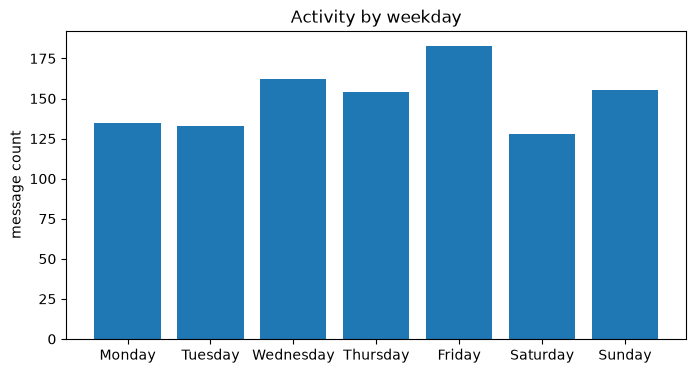

In [8]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly = df.groupby("weekday").size().reindex(weekday_order, fill_value=0)

plt.figure(figsize=(8, 4))
plt.bar(weekly.index, weekly.values)
plt.ylabel("message count")
plt.title("Activity by weekday")
plt.show()

## 月度趋势

验证 `DAY_WEIGHTS = linspace(0.5, 1.5, ...)` 这个埋好的"全年缓慢增长"模式——按月份分组之后应该大致是一条从左到右往上走的曲线，允许月份之间有些抖动（毕竟只采样了150次对话）。

这里用折线图而不是柱状图，因为月份是有先后顺序的连续维度，看趋势用折线更直观。

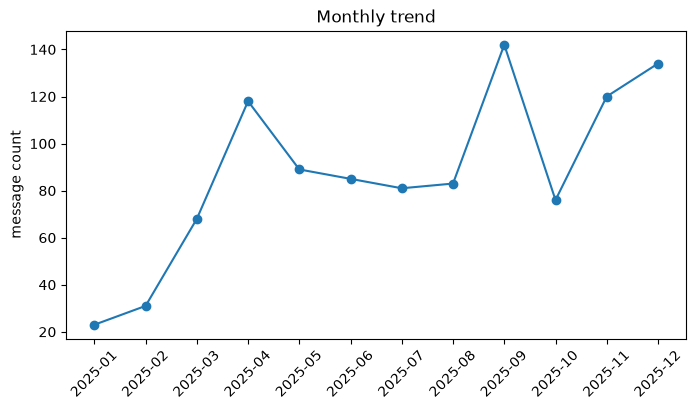

In [9]:
monthly = df.groupby("month").size().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.xticks(rotation=45)
plt.ylabel("message count")
plt.title("Monthly trend")
plt.show()

## 对话长度分布

之前几张图都是「消息级」统计，这次换成「对话级」：每个 `conversation_id` 一共有几条消息（user+assistant 加起来）。

做法：按 `conversation_id` 分组，取 `turn` 列的最大值再 +1（因为 `turn` 是从0开始计数的）。预期分布应该和生成代码里的 `n_turns = rng.integers(2, 13)` 对得上——大致在 2~12 之间均匀分布。

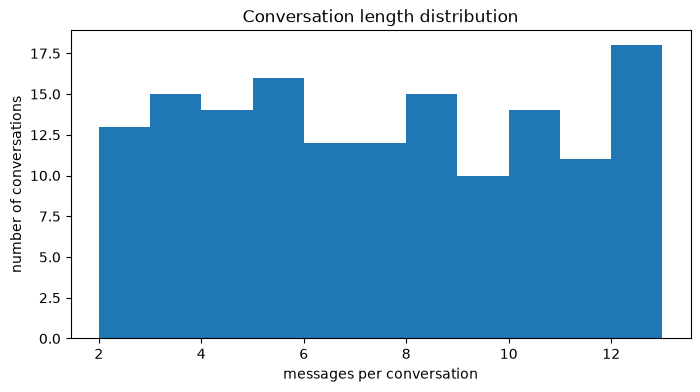

count    150.000000
mean       7.000000
std        3.250194
min        2.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       12.000000
Name: turn, dtype: float64

In [10]:
conv_lengths = df.groupby("conversation_id")["turn"].max() + 1

plt.figure(figsize=(8, 4))
plt.hist(conv_lengths, bins=range(2, 14))
plt.xlabel("messages per conversation")
plt.ylabel("number of conversations")
plt.title("Conversation length distribution")
plt.show()

conv_lengths.describe()

# 阶段 2：Embedding + 聚类

把每个对话聚合成一条文档 → 编码成向量 → KMeans 聚类（elbow 选 k）→ c-TF-IDF 提主题词。

In [11]:
conv_docs = df.groupby("conversation_id")["text"].apply(lambda texts: " ".join(texts)).reset_index()
conv_docs.columns = ["conversation_id", "doc"]
conv_docs.shape, conv_docs.head(2)

((150, 2),
   conversation_id                                                doc
 0       conv_0001           这两个概念有什么区别（概念学习，第1轮） 能不能讲讲这个原理（概念学习，第2轮）
 1       conv_0002  要不要跳槽（求职规划，第1轮） 面试官可能会问什么（求职规划，第2轮） 这份简历怎么改（求职...)

In [12]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(conv_docs["doc"].tolist(), normalize_embeddings=True, show_progress_bar=True)
embeddings.shape

Batches: 100%|██████████| 5/5 [00:02<00:00,  2.27it/s]


(150, 384)

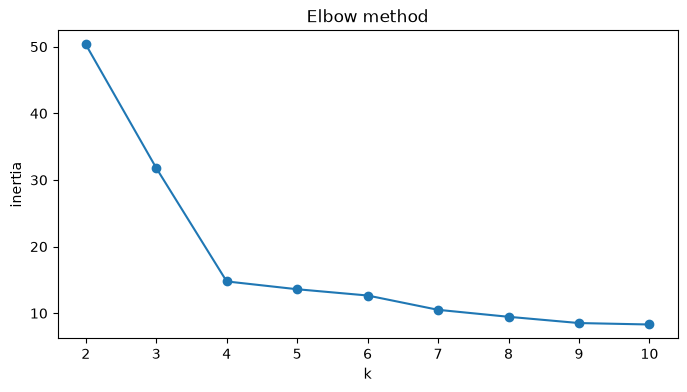

In [17]:
from sklearn.cluster import KMeans

inertias = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(embeddings)
    inertias[k] = km.inertia_

plt.figure(figsize=(8, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

In [18]:
km = KMeans(n_clusters=4, random_state=42, n_init="auto")
conv_docs["cluster"] = km.fit_predict(embeddings)
conv_docs["cluster"].value_counts().sort_index()

cluster
0    37
1    39
2    39
3    35
Name: count, dtype: int64

In [19]:
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer

tokenized_docs = [" ".join(jieba.cut(doc)) for doc in conv_docs["doc"]]
vectorizer = TfidfVectorizer(max_features=2000)
tfidf = vectorizer.fit_transform(tokenized_docs)
terms = vectorizer.get_feature_names_out()

for cluster_id in sorted(conv_docs["cluster"].unique()):
    mask = (conv_docs["cluster"] == cluster_id).values
    scores = tfidf[mask].mean(axis=0).A1
    top_idx = scores.argsort()[::-1][:8]
    print(cluster_id, [terms[i] for i in top_idx])

0 ['求职', '规划', '跳槽', '不要', '可能', '面试官', '这份', '简历']
1 ['润色', '写作', '开头', '一段', '这段话', '这句', '表达', '自然']
2 ['概念学习', '这个', '推导', '公式', '概念', '区别', '两个', '讲讲']
3 ['代码', '调试', '这个', '看看', 'bug', '异常', '为什么', '函数']


# 阶段 3：语义搜索

embedding 已经归一化，cosine similarity = 点积，直接对查询向量和所有对话向量做矩阵乘法排序。

In [20]:
def search(query, top_k=3):
    query_vec = model.encode([query], normalize_embeddings=True)[0]
    scores = embeddings @ query_vec
    top_idx = scores.argsort()[::-1][:top_k]
    return conv_docs.iloc[top_idx].assign(score=scores[top_idx])

search("我应该怎么改简历")

,conversation_id,doc,cluster,score
63,conv_0064,这份简历怎么改（求职规划，第1轮） 要不要跳槽（求职规划，第2轮）,0,0.79057
67,conv_0068,要不要跳槽（求职规划，第1轮） 这份简历怎么改（求职规划，第2轮）,0,0.71166
40,conv_0041,这份简历怎么改（求职规划，第1轮） 这份简历怎么改（求职规划，第2轮）,0,0.69002
